# Images alignment on S3/S2

This notebook presents some examples of imagery alignment techniques introduced in the previous notebook on the real-life example of aligning Sentinel-2 and Sentinel-3 OLCI imagery.

## Load in data needed

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt

save_path = '/content/drive/MyDrive/GEOL0069/2425/Week 5/Regression_application'
s2_data = np.load(save_path+'/s2_zoomed_data.npz')
s2_x = s2_data['x']
s2_y = s2_data['y']
s2_band_data = s2_data['band_data']

s3_data = np.load(save_path+'/s3_zoomed_data.npz')
s3_x = s3_data['x']
s3_y = s3_data['y']
s3_reflectance = s3_data['reflectance']



You don't need to run this cell. This cell mainly interpolates the loaded S3/S2 scene to a common grid for alignment.
```python
import numpy as np
from scipy.interpolate import griddata

def process_and_save_data(
    x_s2, y_s2, s2_band_data, s2_band_index,
    x_s3, y_s3, s3_reflectance, s3_band_index,
    ngrid=400, out_file='interpolated_data.npz'
):
    # Pick single band
    s2_vals = s2_band_data[:, s2_band_index]
    s3_vals = s3_reflectance[:, s3_band_index]

    x_min = min(x_s3.min(), x_s2.min())
    x_max = max(x_s3.max(), x_s2.max())
    y_min = min(y_s3.min(), y_s2.min())
    y_max = max(y_s3.max(), y_s2.max())

    x_grid = np.linspace(x_min, x_max, ngrid)
    y_grid = np.linspace(y_min, y_max, ngrid)
    xg, yg = np.meshgrid(x_grid, y_grid)

    z_s2 = griddata((x_s2, y_s2), s2_vals, (xg, yg), method='cubic')
    z_s3 = griddata((x_s3, y_s3), s3_vals, (xg, yg), method='cubic')

    np.savez_compressed(out_file, xg=xg, yg=yg, z_s2=z_s2, z_s3=z_s3)
    print(f"Saved precomputed arrays to '{out_file}'")

process_and_save_data(
    s2_x, s2_y, s2_band_data, 0,
    s3_x, s3_y, s3_reflectance, 0,
    ngrid=400,
    out_file='/content/drive/MyDrive/GEOL0069/2324/Week 6 2025/interpolated_data.npz'
)

```

In [5]:
def load_precomputed_data(file='interpolated_data.npz'):
    data = np.load(file)
    xg = data['xg']
    yg = data['yg']
    z_s2 = data['z_s2']
    z_s3 = data['z_s3']
    print(f"Loaded arrays from '{file}' (shapes: {z_s2.shape}, {z_s3.shape})")
    return xg, yg, z_s2, z_s3


xg, yg, z_s2, z_s3 = load_precomputed_data('/content/drive/MyDrive/PhD Year 3/GEOL0069_test_2026/Week 6/interpolated_data.npz')


Loaded arrays from '/content/drive/MyDrive/PhD Year 3/GEOL0069_test_2026/Week 6/interpolated_data.npz' (shapes: (400, 400), (400, 400))


## Auto-correlation

[AutoCorr] Manual shift=(10,-5), Recovered=(12,-7)


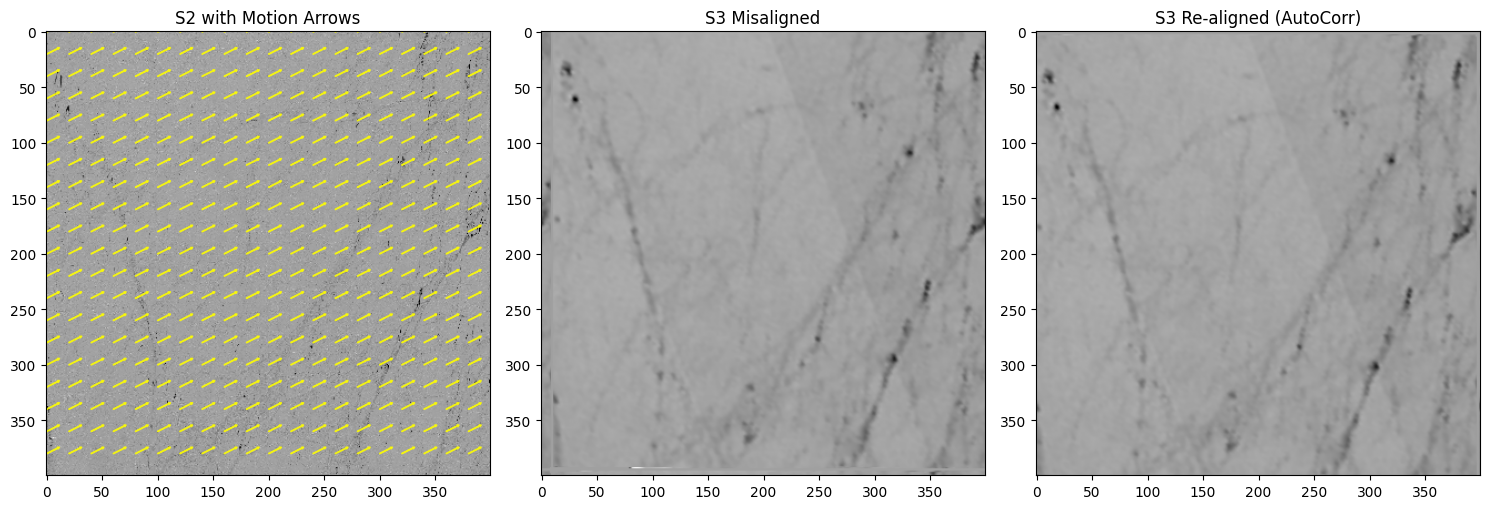

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow
from scipy.signal import correlate2d

def auto_corr_demo_with_arrows(
    z_s2, z_s3,
    manual_dx=15,
    manual_dy=-7,
    step=20
):
    A = np.nan_to_num(z_s2, nan=np.nanmean(z_s2))
    B = np.nan_to_num(z_s3, nan=np.nanmean(z_s3))

    B_misaligned = np.roll(np.roll(B, manual_dy, axis=0), manual_dx, axis=1)

    corr = correlate2d(A, B_misaligned, mode='same', boundary='wrap')
    peak_y, peak_x = np.unravel_index(np.argmax(corr), corr.shape)

    shift_x_btoa = peak_x - B_misaligned.shape[1]//2
    shift_y_btoa = peak_y - B_misaligned.shape[0]//2

    dx_est = -shift_x_btoa
    dy_est = -shift_y_btoa

    print(f"[AutoCorr] Manual shift=({manual_dx},{manual_dy}), Recovered=({dx_est},{dy_est})")

    B_realigned = np.roll(np.roll(B_misaligned, shift_y_btoa, axis=0),
                          shift_x_btoa, axis=1)

    fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(15, 5))

    axA.imshow(A, cmap='gray')
    axA.set_title("S2 with Motion Arrows")

    h, w = A.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)

    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, manual_dx, manual_dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    axB.imshow(B_misaligned, cmap='gray')
    axB.set_title("S3 Misaligned")

    axC.imshow(B_realigned, cmap='gray')
    axC.set_title("S3 Re-aligned (AutoCorr)")

    plt.tight_layout()
    plt.show()

# Example usage:
auto_corr_demo_with_arrows(z_s2, z_s3, manual_dx=10, manual_dy=-5, step=20)


## Phase correlation

[PhaseCorr] Manual shift=(10,-5), Recovered=(11.00,-7.00)


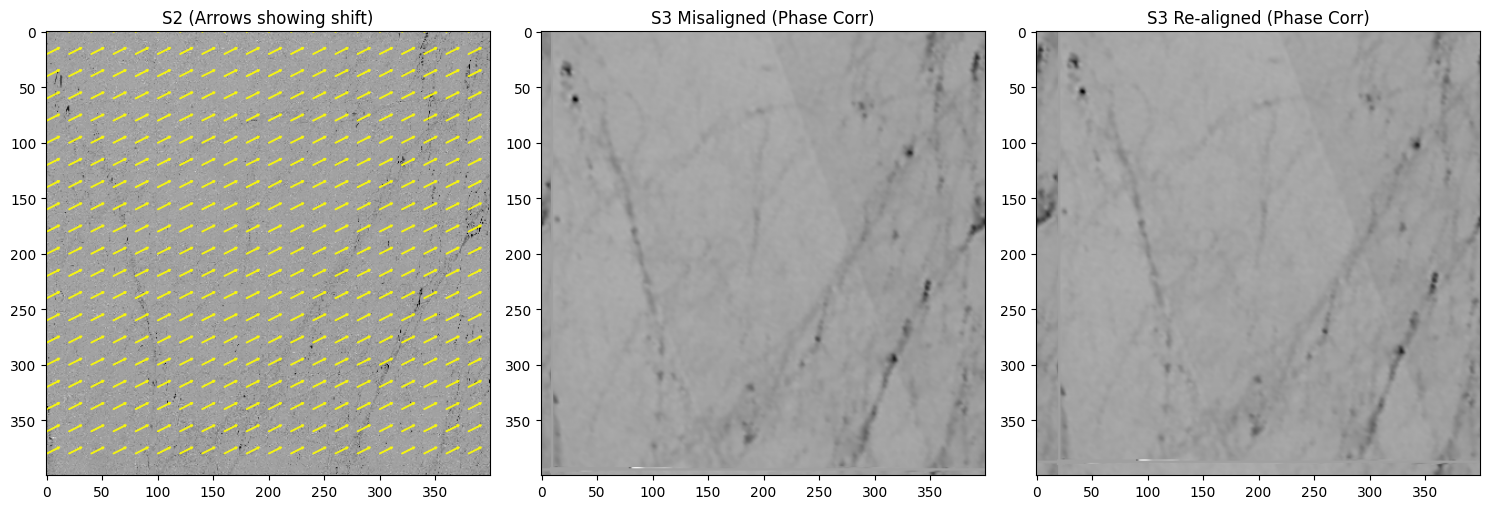

In [7]:
from skimage.registration import phase_cross_correlation


def phase_corr_demo_with_arrows(
    z_s2, z_s3,
    manual_dx=15,
    manual_dy=-7,
    step=20
):
    A = np.nan_to_num(z_s2, nan=np.nanmean(z_s2))
    B = np.nan_to_num(z_s3, nan=np.nanmean(z_s3))

    B_misaligned = np.roll(np.roll(B, manual_dy, axis=0), manual_dx, axis=1)

    shift, error, diffphase = phase_cross_correlation(A, B_misaligned)
    dy_est, dx_est = shift
    dx_est, dy_est = -dx_est, -dy_est
    print(f"[PhaseCorr] Manual shift=({manual_dx},{manual_dy}), Recovered=({dx_est:.2f},{dy_est:.2f})")

    B_realigned = np.roll(np.roll(B_misaligned, int(dy_est), axis=0),
                          int(dx_est), axis=1)

    fig, (axA, axB, axC) = plt.subplots(1,3, figsize=(15,5))

    axA.imshow(A, cmap='gray')
    axA.set_title(f"S2 (Arrows showing shift)")
    h, w = A.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)
    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, manual_dx, manual_dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    axB.imshow(B_misaligned, cmap='gray')
    axB.set_title("S3 Misaligned (Phase Corr)")

    axC.imshow(B_realigned, cmap='gray')
    axC.set_title("S3 Re-aligned (Phase Corr)")

    plt.tight_layout()
    plt.show()

phase_corr_demo_with_arrows(z_s2, z_s3, manual_dx=10, manual_dy=-5, step=20)


## ECC (Enhanced Correlation Coefficient) Alignment

[ECC] Manual shift=(10,-5), Recovered=(10.94,-7.87), CC=0.7336


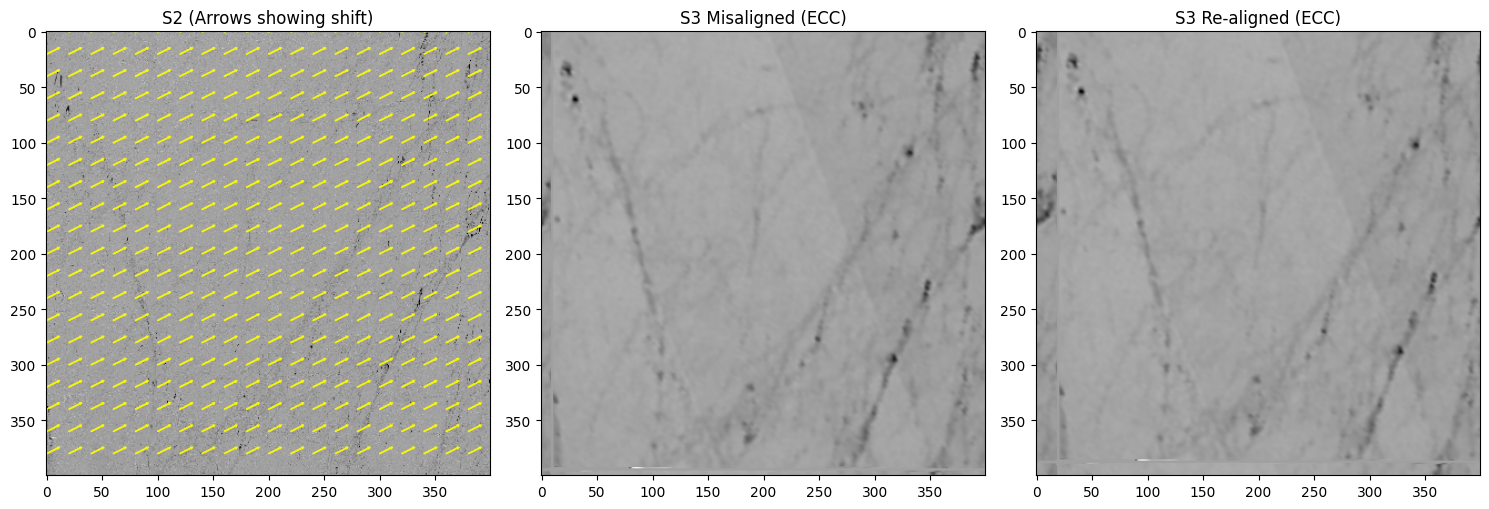

In [8]:

import cv2


def ecc_demo_with_arrows(
    z_s2, z_s3,
    manual_dx=15,
    manual_dy=-7,
    step=20,
    iterations=200,
    eps=1e-6
):
    A = np.nan_to_num(z_s2, nan=np.nanmean(z_s2)).astype(np.float32)
    B = np.nan_to_num(z_s3, nan=np.nanmean(z_s3)).astype(np.float32)

    B_misaligned = np.roll(np.roll(B, manual_dy, axis=0), manual_dx, axis=1)

    warp_matrix = np.eye(2, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iterations, eps)

    try:
        cc, warp_matrix = cv2.findTransformECC(A, B_misaligned, warp_matrix, motionType=cv2.MOTION_TRANSLATION, criteria=criteria)
        dx_est, dy_est = warp_matrix[0,2], warp_matrix[1,2]
        print(f"[ECC] Manual shift=({manual_dx},{manual_dy}), Recovered=({dx_est:.2f},{dy_est:.2f}), CC={cc:.4f}")
    except cv2.error as e:
        print("[ECC Failed]", e)
        dx_est, dy_est = None, None

    B_realigned = np.roll(np.roll(B_misaligned, int(dy_est), axis=0),
                          int(dx_est), axis=1)

    fig, (axA, axB, axC) = plt.subplots(1,3, figsize=(15,5))

    axA.imshow(A, cmap='gray')
    axA.set_title(f"S2 (Arrows showing shift)")
    h, w = A.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)
    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, manual_dx, manual_dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    axB.imshow(B_misaligned, cmap='gray')
    axB.set_title("S3 Misaligned (ECC)")

    axC.imshow(B_realigned, cmap='gray')
    axC.set_title("S3 Re-aligned (ECC)")

    plt.tight_layout()
    plt.show()

ecc_demo_with_arrows(z_s2, z_s3, manual_dx=10, manual_dy=-5, step=20)


## Sea-Raft

In [11]:
# Install required deep learning, image processing, and visualization libraries
!pip install torch torchvision opencv-python matplotlib

# OS utilities (file system checks, paths)
import os
# System utilities (used to modify Python path)
import sys
# Deep learning framework
import torch
# Numerical computations
import numpy as np
# Computer vision library
import cv2
# Visualization
import matplotlib.pyplot as plt
# Image loading / manipulation
from PIL import Image

# Download SEA-RAFT if it is not already available
if not os.path.exists("SEA-RAFT"):
    !git clone https://github.com/princeton-vl/SEA-RAFT.git
else:
    print("SEA-RAFT folder exists — skipping clone")

# Simple container for configuration objects
from types import SimpleNamespace
# Allows Python to find RAFT modules inside the repository
sys.path.append("SEA-RAFT/core")
# Main RAFT model class
from raft import RAFT
# Utility for padding images to dimensions compatible with the network
from utils.utils import InputPadder

Cloning into 'SEA-RAFT'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 115 (delta 28), reused 22 (delta 22), pack-reused 75 (from 1)
Receiving objects: 100% (115/115), 8.16 MiB | 17.49 MiB/s, done.
Resolving deltas: 100% (51/51), done.


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


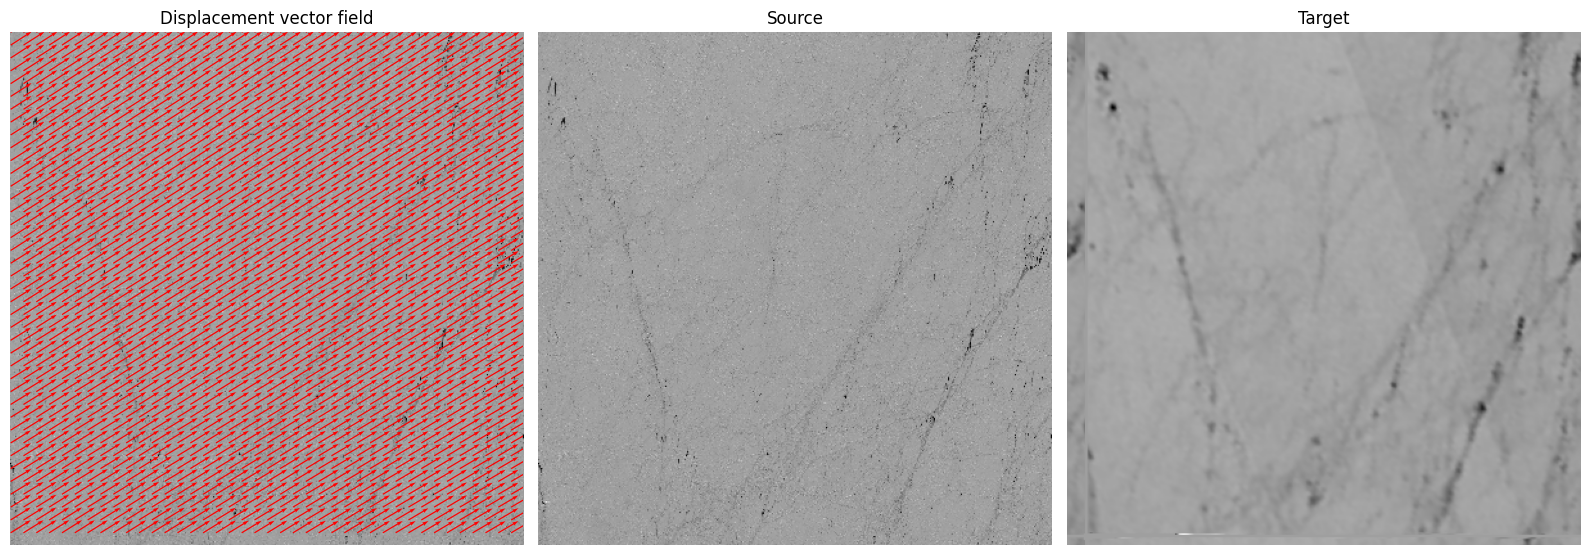

In [14]:
def grayscale_to_rgb(img, normalize=True):
    """
    Convert a single-channel grayscale image to a 3-channel RGB image.

    SEA‑RAFT expects RGB images as input.

    This function converts a grayscale image
    to RGB by replicating the grayscale channel across the three RGB channels.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image of shape (H, W).
    normalize : bool, optional (default=True)
        If True, the image will be normalized to the [0, 255] range.
        For real data, additional preprocessing (e.g., contrast enhancement)
        may be required.

    Returns
    -------
    rgb_img : np.ndarray
        RGB image of shape (H, W, 3), dtype=np.uint8.
    """
    if img.ndim != 2:
        raise ValueError("Input image must be single-channel (H, W)")

    img_out = img.copy()

    if normalize:
        img_min, img_max = img_out.min(), img_out.max()
        if img_max > img_min:
            img_out = (img_out - img_min) / (img_max - img_min)
        img_out = (img_out * 255).astype(np.uint8)
    else:
        img_out = img_out.astype(np.uint8)

    # Stack into 3 identical channels
    rgb_img = np.stack([img_out, img_out, img_out], axis=-1)

    return rgb_img

def sea_raft_flow(img1, img2, model_path=None, device='cpu'):
    """
    Estimate dense optical flow (displacement field) between two RGB images using SEA‑RAFT.

    Parameters
    ----------
    img1 : np.ndarray
        Source RGB image of shape (H, W, 3), dtype=np.uint8 or float.
    img2 : np.ndarray
        Target RGB image of shape (H, W, 3), dtype=np.uint8 or float.
    model_path : str, optional
        Path to pre-trained SEA‑RAFT weights. If None, defaults to the standard model path.
    device : str, optional
        Device to run the model on ('cpu' or 'cuda').

    Returns
    -------
    u_disp : np.ndarray
        Horizontal displacement (dx) for each pixel, shape (H, W).
    v_disp : np.ndarray
        Vertical displacement (dy) for each pixel, shape (H, W).
    """

    # Default dictionary storing standard SEARaft parameters/arguments
    args_dict = {
        "name": "spring-M",
        "dataset": "spring",
        "gpus": [0,1,2,3,4,5,6,7],
        "use_var": True,
        "var_min": 0,
        "var_max": 10,
        "pretrain": "resnet34",
        "initial_dim": 64,
        "block_dims": [64,128,256],
        "radius": 4,
        "dim": 128,
        "num_blocks": 2,
        "iters": 4,
        "image_size": [540,960],
        "scale": -1,
        "batch_size": 32,
        "epsilon": 1e-08,
        "lr": 0.0004,
        "wdecay": 1e-05,
        "dropout": 0,
        "clip": 1.0,
        "gamma": 0.85,
        "num_steps": 120000,
        "restore_ckpt": None,
        "coarse_config": None,
        "cfg": "SEA-RAFT/config/eval/spring-M.json",
        "path": "/content/drive/MyDrive/PhD Year 3/GEOL0069_test_2026/Week 6/Tartan-C-T-TSKH-spring540x960-M.pth",
        "url": None,
        "device": device
    }

    # Convert the dictionary to an arg namespace (compatibility)
    args = SimpleNamespace(**args_dict)

    # Instantiate the RAFT model
    model = RAFT(args)
    model_path = args.path
    if model_path:
        model.load_state_dict(torch.load(model_path,map_location=torch.device(device)))
    model.to(device)
    model.eval()

    # Convert input images to tensors
    img1_t = torch.from_numpy(img1).permute(2,0,1).float()[None].to(device)
    img2_t = torch.from_numpy(img2).permute(2,0,1).float()[None].to(device)

    # Pad to multiple of 8 (constraint related to the architecture design)
    padder = InputPadder(img1_t.shape)
    img1_t, img2_t = padder.pad(img1_t, img2_t)

    # Evaluation
    with torch.no_grad():
        outputs = model(img1_t, img2_t, iters=20, test_mode=True)
        flow = outputs['flow'][-1]  # last iteration

    # Extract the horizontal and vertical flow (displacement) dx, dy
    flow = flow.squeeze(0)         # remove batch -> shape (2, H, W)
    flow = flow.permute(1,2,0)     # (H, W, 2)

    u_disp = flow[...,0].cpu().numpy()  # horizontal
    v_disp = flow[...,1].cpu().numpy()  # vertical

    return u_disp, v_disp

A = np.nan_to_num(z_s2, nan=np.nanmean(z_s2))
B = np.nan_to_num(z_s3, nan=np.nanmean(z_s3))
manual_dx=15
manual_dy=-7,
B_misaligned = np.roll(np.roll(B, manual_dy, axis=0), manual_dx, axis=1)

A = grayscale_to_rgb(A)
B_misaligned = grayscale_to_rgb(B_misaligned)

dx_raft_AB, dy_raft_AB = sea_raft_flow(A, B_misaligned, model_path=None)

# Display
skip=10
fig, axes = plt.subplots(1, 3, figsize=(16,8))
h1, w1 = dx_raft_AB.shape
Y1, X1 = np.mgrid[0:h1, 0:w1]
axes[0].imshow(A)
axes[0].quiver(X1[::skip, ::skip], Y1[::skip, ::skip],
        dx_raft_AB[::skip, ::skip], dy_raft_AB[::skip, ::skip],
        angles='xy', scale_units='xy', scale=1, color='red'
    )
axes[0].set_title("Displacement vector field")
axes[0].axis('off')
#######
h2, w2 = dx_raft_AB.shape
Y2, X2 = np.mgrid[0:h2, 0:w2]
axes[1].imshow(A)
axes[1].set_title("Source")
axes[1].axis('off')
#######
h3, w3 = dx_raft_AB.shape
Y3, X3 = np.mgrid[0:h3, 0:w3]
axes[2].imshow(B_misaligned)
axes[2].set_title("Target")
axes[2].axis('off')
plt.tight_layout()
plt.show()